In [8]:
import sys
import numpy as np
import os
import json

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain_1200000_steps.h5"
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/675-50nm_no_IMR_offset_or_IMR_and_HWP_constraints.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/610nm_Adjusted_EM_Gain.txt"


# Step 1: Defining System Dictionary

In [9]:
filter_wavelength = 610
wavelength_string = filter_wavelength
wavelength_index = 0
nsteps = 1200000
obs_mode = "MBI"

IPOL_em_gains = [1.14, 1.18, 1.18, 1.18]
MBI_em_gains = [1.23, 1.19, 1.2, 1.08]
if obs_mode == "IPOL":
    em_gain = IPOL_em_gains[wavelength_index]
elif obs_mode == "MBI":
    em_gain = MBI_em_gains[wavelength_index]

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

# Step 2: Loading Chains

Using max posterior sample at step=181026, walker=13, log_prob=496.183258
dichroic.phi (waves): 0.02524
dichroic.epsilon (): 0.52614
dichroic.theta (): 45.59846
flc.phi (waves): 0.48575
flc.delta_theta (): -4.51679
optics.phi (waves): 0.17530
optics.epsilon (): 0.01848
optics.theta (): 7.10697
image_rotator.phi (waves): 0.21883
hwp.phi (waves): 0.44093
hwp.delta_theta (): -0.25109
lp.theta (): 0.01941
log_f (): -8.23476
Summary mode: max_posterior
Summary step range: (0, None)
Max posterior metadata: {'step': 181026, 'walker': 13, 'log_prob': 496.1832580566406}
Chain shape (nsteps, nwalkers, ndim): (1200000, 28, 13)


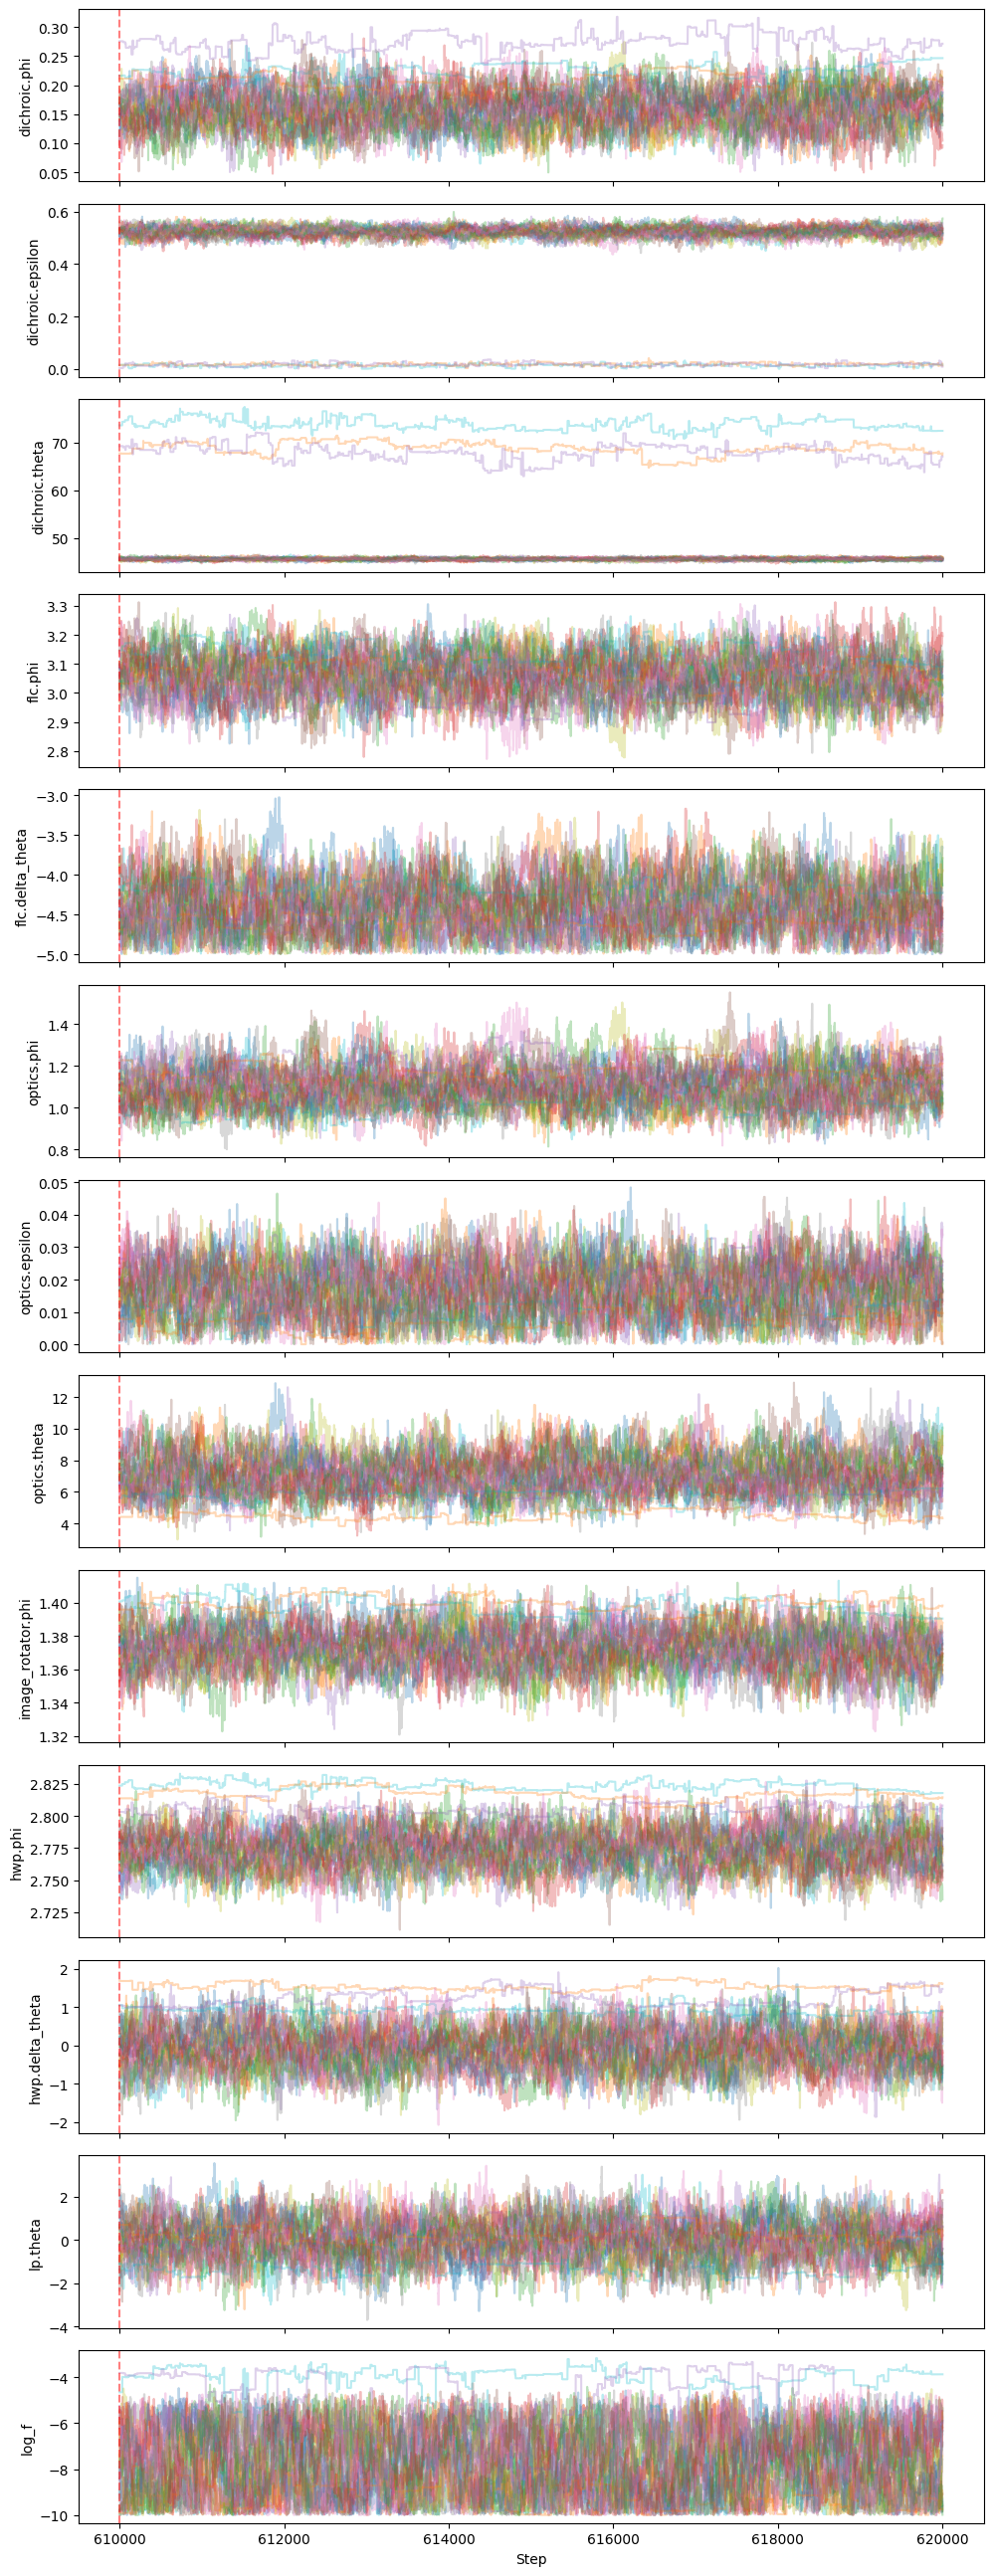

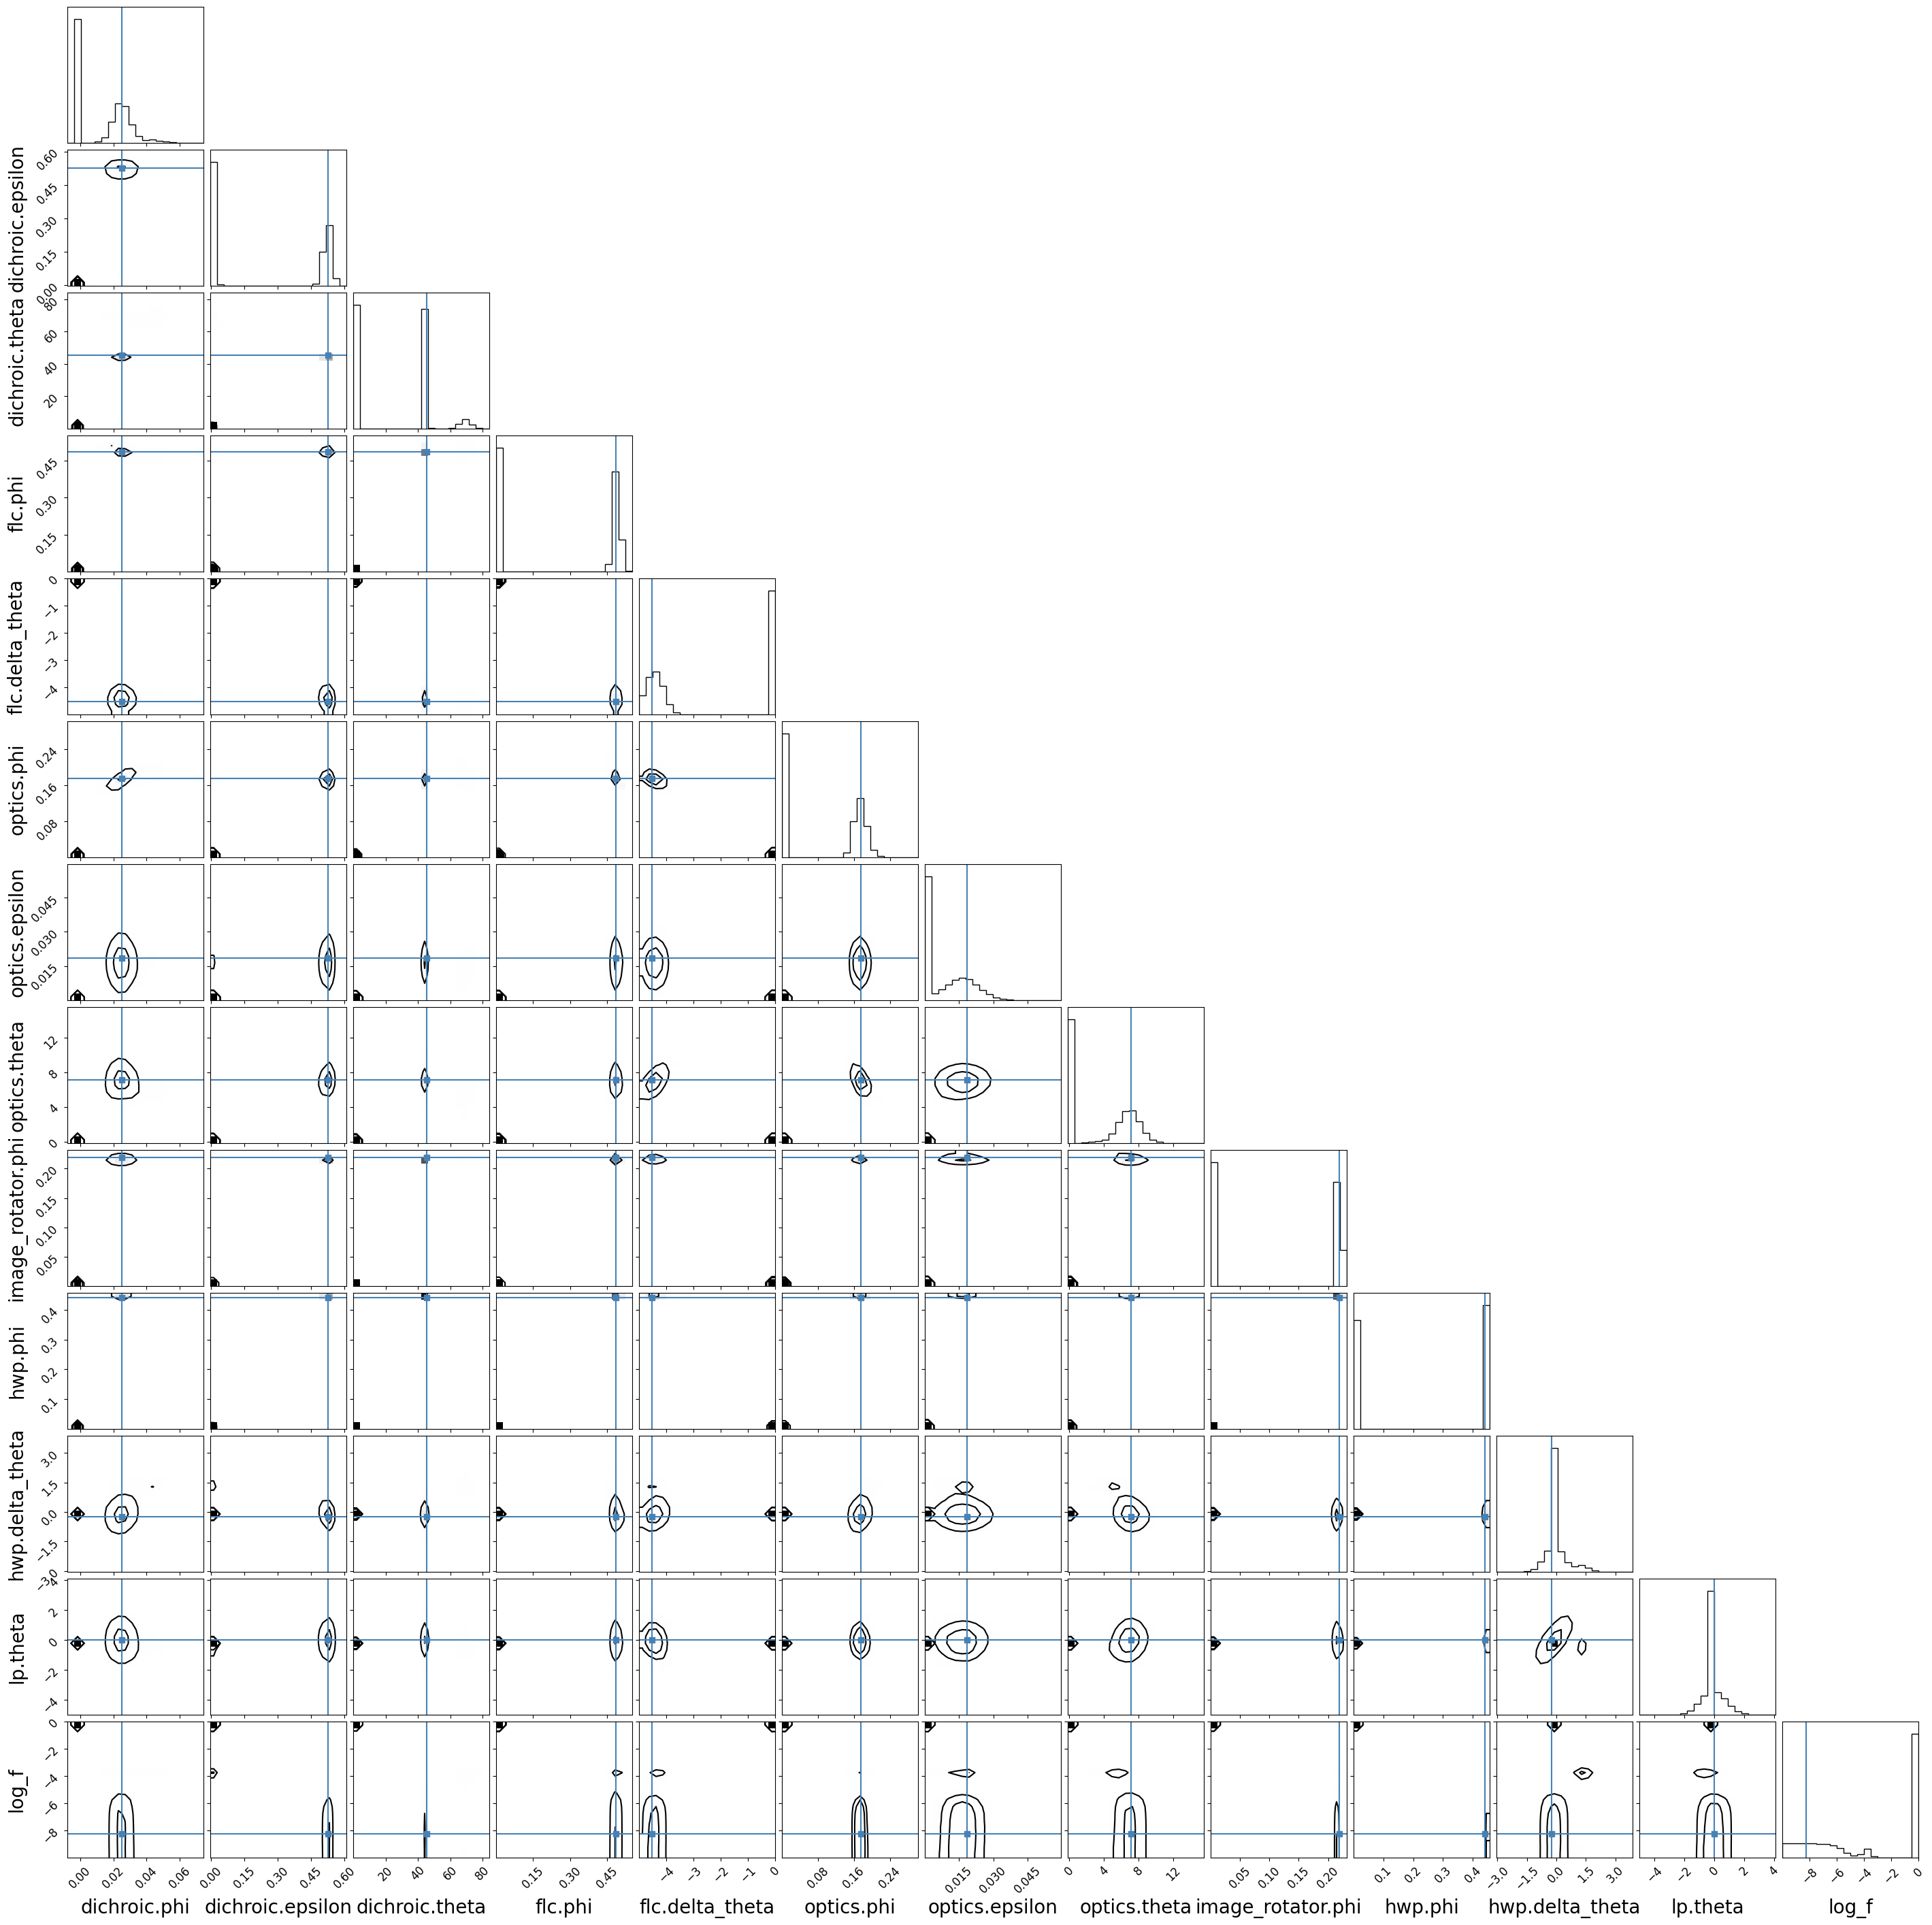

In [10]:
import h5py
import corner
import matplotlib.pyplot as plt


def _validate_step_range(chain, step_range):
    nsteps = chain.shape[0]
    start, end = step_range
    if end is None:
        end = nsteps
    if start >= end or start >= nsteps:
        raise ValueError(f"Invalid step_range {step_range} for chain with {nsteps} steps.")
    return start, end


def _flatten_chain_converted(chain, param_names, step_range):
    start, end = _validate_step_range(chain, step_range)
    flat_chain = chain[start:end, :, :].reshape(-1, chain.shape[-1]).copy()
    for i, name in enumerate(param_names):
        if ".phi" in name:
            flat_chain[:, i] = flat_chain[:, i] / (2 * np.pi)
    return flat_chain


def _nested_fit_dict(param_names, selected_values):
    fit_dict = {}
    for name, val in zip(param_names, selected_values):
        if "." in name:
            comp, param = name.split(".", 1)
            if comp not in fit_dict:
                fit_dict[comp] = {}
            fit_dict[comp][param] = float(val)
    return fit_dict


def plot_corner_selected_truths(chain, param_names, step_range, selected_values):
    flat_chain = _flatten_chain_converted(chain, param_names, step_range)
    truths = np.asarray(selected_values)

    fig = corner.corner(
        flat_chain,
        labels=[label.replace(".phi", ".phi") for label in param_names],
        truths=truths,
        plot_datapoints=False,
    )

    for ax in fig.get_axes():
        ax.tick_params(axis="both", labelsize=12)
        ax.xaxis.label.set_size(20)
        ax.yaxis.label.set_size(20)
        ax.xaxis.labelpad = 40
        ax.yaxis.labelpad = 40

    plt.tick_params(axis="x", which="both", pad=5)
    plt.tick_params(axis="y", which="both", pad=5)
    plt.show()


def summarize_posteriors_toggle(
    chain,
    param_names,
    system_dict,
    txt_file_path,
    txt_save_file_path,
    step_range,
    mode="median",
    h5_path=None,
):
    """Toggle between original median summary and max-posterior summary."""
    start, end = _validate_step_range(chain, step_range)
    flat_chain = chain[start:end, :, :].reshape(-1, chain.shape[-1])

    if mode == "median":
        # Keep original behavior exactly as implemented in plotting_rewrite.
        plotting.summarize_posteriors(
            chain,
            param_names,
            system_dict,
            txt_file_path=txt_file_path,
            txt_save_file_path=txt_save_file_path,
            step_range=step_range,
        )

        selected_values = []
        for i, name in enumerate(param_names):
            vals = flat_chain[:, i] / (2 * np.pi) if ".phi" in name else flat_chain[:, i]
            selected_values.append(float(np.median(vals)))

        fit_dict = _nested_fit_dict(param_names, selected_values)
        return {
            "mode": mode,
            "fit_dict": fit_dict,
            "selected_values": selected_values,
            "step_idx": None,
            "walker_idx": None,
            "best_log_prob": None,
        }

    if mode != "max_posterior":
        raise ValueError("mode must be 'median' or 'max_posterior'.")

    if h5_path is None:
        raise ValueError("h5_path is required for mode='max_posterior'.")

    with h5py.File(h5_path, "r") as f:
        log_prob = f["mcmc"]["log_prob"][start:end, :]

    local_step_idx, walker_idx = np.unravel_index(np.argmax(log_prob), log_prob.shape)
    step_idx = start + local_step_idx
    best_sample = chain[step_idx, walker_idx, :]
    best_log_prob = float(log_prob[local_step_idx, walker_idx])

    selected_values = []
    print(f"Using max posterior sample at step={step_idx}, walker={walker_idx}, log_prob={best_log_prob:.6f}")
    for i, name in enumerate(param_names):
        val = best_sample[i] / (2 * np.pi) if ".phi" in name else best_sample[i]
        selected_values.append(float(val))
        units = "waves" if ".phi" in name else ""
        print(f"{name} ({units}): {val:.5f}")

    fit_dict = _nested_fit_dict(param_names, selected_values)

    if txt_save_file_path is not None:
        with open(txt_save_file_path, "w") as f:
            json.dump(fit_dict, f, indent=4)

    return {
        "mode": mode,
        "fit_dict": fit_dict,
        "selected_values": selected_values,
        "step_idx": int(step_idx),
        "walker_idx": int(walker_idx),
        "best_log_prob": best_log_prob,
    }


chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf=True)
chain_step_range = (610000, 620000)
corner_plot_step_range = (619000, 620000)

# Use max posterior by default so summary output and blue truth lines match the max posterior sample.
# Options: "max_posterior" or "median"
summary_mode = "max_posterior"

summary_result = summarize_posteriors_toggle(
    chain,
    names,
    system_dict,
    txt_file_path=txt_file_path,
    txt_save_file_path=txt_save_file_path,
    step_range=corner_plot_step_range,
    mode=summary_mode,
    h5_path=h5_file_path,
)

selected_fit_dict = summary_result["fit_dict"]
selected_param_values = np.asarray(summary_result["selected_values"])

print("Summary mode:", summary_result["mode"])
if summary_result["mode"] == "max_posterior":
    print(
        "Max posterior metadata:",
        {
            "step": summary_result["step_idx"],
            "walker": summary_result["walker_idx"],
            "log_prob": summary_result["best_log_prob"],
        },
    )

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)

# Plot trace plots for MCMC chains
plotting.plot_trace(chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner with truth lines from the same selected posterior values used in the summary.
plot_corner_selected_truths(chain, names, step_range=corner_plot_step_range, selected_values=selected_param_values)





# Step 3: Plot selected posterior configuration (max posterior by default)


In [11]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)

In [12]:
# Loading selected posterior parameters (from in-memory summary result when available)
if "selected_fit_dict" in globals() and selected_fit_dict is not None:
    past_fit = selected_fit_dict
else:
    with open(txt_save_file_path, "r") as f:
        past_fit = json.load(f)

print("Using posterior mode:", summary_mode)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"]
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"]
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"]
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print(delta_HWP)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic * 2 * np.pi,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts * 2 * np.pi,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": 0,  # not fitted
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())



Using posterior mode: max_posterior
0.44093199675182987
[[4.79387503e-01 4.79387393e-01 3.24741516e-04 0.00000000e+00]
 [4.79387503e-01 4.79387393e-01 3.24741516e-04 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]


logl value: 31142.271348507373


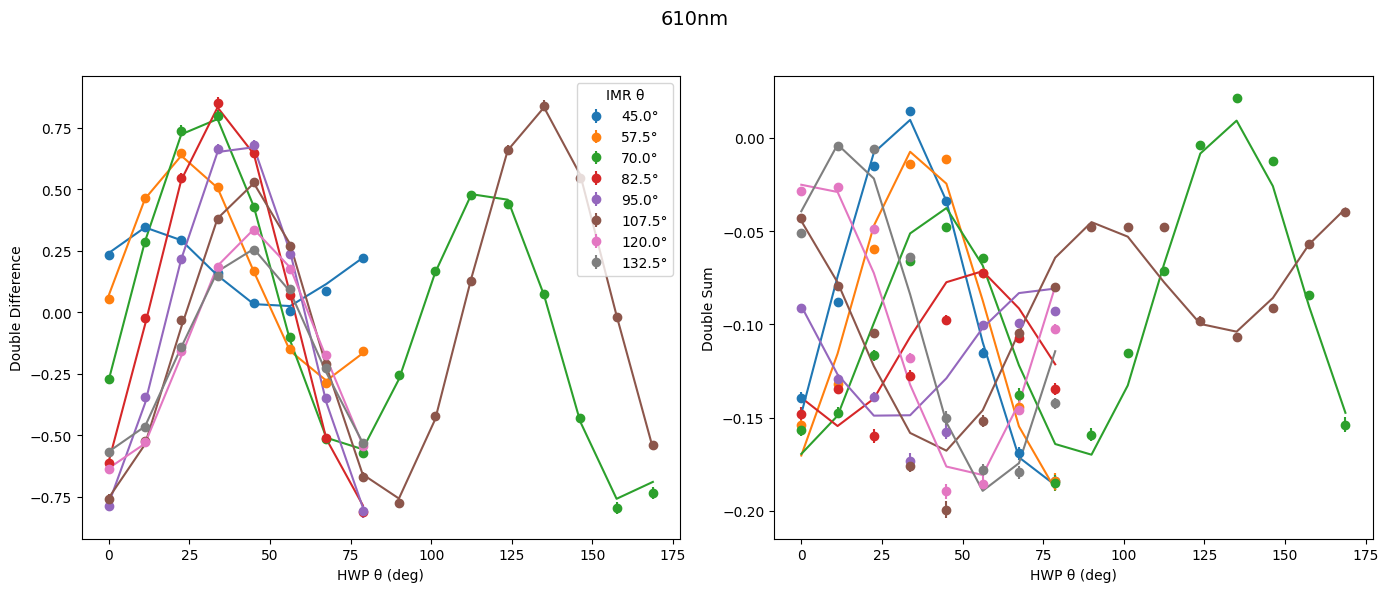

In [13]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
# updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

In [14]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import plotting_rewrite as plotting
# import numpy as np

# all_step_range = (0, None)
# corner_plot_step_range = (24000, 25000)

# # Define the system configuration dictionary
# system_dict = {
#     "components": {
#         "wollaston": {
#             "type": "wollaston_prism_function",
#             "properties": {"beam": "o", "transmission_ratio": 1.18},
#         },
#         "dichroic": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "flc": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "optics": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "image_rotator": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "hwp": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
#         },
#         "lp": {
#             "type": "general_linear_polarizer_function_with_theta",
#             "properties": {"theta": 0},
#         },
#     }
# }

# # Input paths and call plotting function
# h5_filename = "675nm_no_IMR_offset_with_dichroic.h5"
# txt_filename = "675-50nm.txt"
# csv_file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

# plotting.plot_mcmc_fits_double_diff_sum(
#     h5_filename=h5_filename,
#     txt_filename=txt_filename,
#     csv_path=csv_file_path,
#     filter_wavelength="675-50",
#     system_dict=system_dict,
#     wavelength_str="675nm",
#     n_samples=50,
#     step_range = all_step_range
# )
